# Case Study 2 — Report 4

**Hybrid CNN-LSTM + Attention on DE features, with Multi-Source Domain Adaptation**

Student: Sanjeev Veeramani (Matr. 100004303)
Program: M.Sc. Applied Data Science and Analytics, SRH University Heidelberg
Supervisor: Prof. Dr. Binh Vu

---

**Objective.** Test whether three interventions — (i) switching input from raw EEG to DE features, (ii) adding an attention-weighted CNN-LSTM hybrid architecture, and (iii) upgrading from single-source DANN to multi-source MMD alignment — improve on the per-window result obtained with single-source DANN on raw EEG in Report 3.

**Method.** DE features (160-dim per 1-second segment) are reshaped to `(32 channels, 5 bands)` and passed through a CNN-LSTM-Attention extractor: 1D convolution over the channel axis, 2-layer LSTM over the resulting sequence, additive attention pooling over LSTM outputs, and a linear projection to 128-d. Three DA variants per (model, task):
- **plain** — label classifier only, cross-entropy loss.
- **DANN** — R3-style single-source adversarial DA with gradient reversal (control, verifies the R3 finding on the new architecture).
- **MMD** — multi-source alignment via linear Maximum Mean Discrepancy between feature distributions of source subjects within each batch.

**Evaluation.** 32-fold LOSO on DEAP, all 32 subjects, all 40 trials, three tasks (binary valence, binary arousal, 3-class valence). Per-fold accuracy, balanced accuracy, weighted F1, macro precision and recall; pooled confusion matrix. Statistical significance by one-sided t-test on per-fold balanced accuracy against chance.

**Expected pattern.** Report 3 with single-source DANN on raw EEG: 53.80% best. Diagnostic showed that DE features alone add +0.70 pp and DANN implementation is correct — remaining gap is structural. Under multi-source alignment, expected range is 60–68% balanced valence accuracy (matching MS-MDA, DBPM ranges in Report 2 Part 1, Table 2). If MMD does not produce a meaningful improvement, the remaining difference is examined in Report 5, which tests source reliability weighting and a confidence-routed dual head.

**Speed optimizations (accuracy-safe).** DE array preloaded once into GPU VRAM (no per-batch host-to-device transfer); `cudnn.benchmark = True` for auto-selected fastest convolution algorithm; batch size 512 unchanged from Report 3 for direct comparability. Expected runtime: ~1.5–2 hours on Colab Pro L4.

## 1. Setup
Drive mount, GPU check, imports, fixed seed, cudnn benchmark mode.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_ROOT = '/content/drive/MyDrive/case_study_2'
assert os.path.isdir(PROJECT_ROOT), f'Set PROJECT_ROOT correctly. Got {PROJECT_ROOT}'

Mounted at /content/drive


In [2]:
import torch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

Device: NVIDIA L4


In [3]:
import numpy as np, pandas as pd, time, gc, pickle
from pathlib import Path
from tqdm.auto import tqdm

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from torch.autograd import Function

from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             f1_score, precision_score, recall_score,
                             confusion_matrix)
from scipy.stats import ttest_1samp

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True     # auto-select fastest conv (speed-safe)
    torch.backends.cudnn.deterministic = False

## 2. Configuration
Grid of variants (plain / DANN / MMD) × tasks (valence / arousal / 3-class) × 32 folds. Trim `folds_to_run` for smoke tests.

In [4]:
CONFIG = {
    # Input: DE features from Report 2 Part 2 feature engineering
    'data_path':       'processed/X_deap_DE_zscored.npy',   # (N, 160)
    'subject_id_path': 'processed/deap_subject_ids.npy',
    'valence_path':    'processed/y_deap_valence.npy',
    'arousal_path':    'processed/y_deap_arousal.npy',
    'labels_3c_path':  'processed/y_deap_3class.npy',

    'results_dir':    'results/report4_msda',
    'checkpoint_dir': 'checkpoints/report4_msda',

    'tasks':    ['valence', 'arousal', '3class'],
    'variants': ['plain', 'dann', 'mmd'],

    'batch_size':    512,
    'epochs':        20,
    'lr':            1e-3,
    'weight_decay':  1e-4,
    'early_stop_patience': 5,

    # DANN (single-source control) schedule
    'dann_lambda_max':  1.0,
    'dann_ramp_epochs': 10,

    # MMD (multi-source alignment) weight
    'mmd_lambda':       1.0,

    'folds_to_run': None,   # None = all subjects auto-detected from data
}

RESULTS_DIR    = Path(PROJECT_ROOT) / CONFIG['results_dir']
CHECKPOINT_DIR = Path(PROJECT_ROOT) / CONFIG['checkpoint_dir']
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

## 3. Data — DE features preloaded to GPU
DE features are 90 MB — fit entirely in L4 VRAM. Preloading eliminates the CPU→GPU transfer overhead that dominated Report 3 wall time.

In [5]:
def load_data():
    root = Path(PROJECT_ROOT)
    X = np.load(root / CONFIG['data_path']).astype(np.float32)
    subj = np.load(root / CONFIG['subject_id_path'])
    labels = {
        'val_bin': np.load(root / CONFIG['valence_path']).astype(np.int64),
        'aro_bin': np.load(root / CONFIG['arousal_path']).astype(np.int64),
        'val_3c':  np.load(root / CONFIG['labels_3c_path']).astype(np.int64),
    }
    return X, subj, labels

X_np, SUBJ_np, LABELS_np = load_data()
UNIQUE_SUBJECTS = np.unique(SUBJ_np)
N_SUBJECTS = len(UNIQUE_SUBJECTS)

# Preload to GPU — the key speedup
X_gpu    = torch.from_numpy(X_np).to(DEVICE)                       # (N, 160) float32
SUBJ_gpu = torch.from_numpy(SUBJ_np.astype(np.int64)).to(DEVICE)   # (N,) int64
LABELS_gpu = {k: torch.from_numpy(v).to(DEVICE) for k, v in LABELS_np.items()}

print(f'X: {X_np.shape}  (~{X_np.nbytes / 1e6:.1f} MB on GPU)')
print(f'Subjects ({N_SUBJECTS}): {UNIQUE_SUBJECTS.tolist()}')
print(f'val_bin: {np.bincount(LABELS_np["val_bin"])}')
print(f'aro_bin: {np.bincount(LABELS_np["aro_bin"])}')
print(f'val_3c:  {np.bincount(LABELS_np["val_3c"])}')

X: (152320, 160)  (~97.5 MB on GPU)
Subjects (32): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
val_bin: [68068 84252]
aro_bin: [64617 87703]
val_3c:  [56168 26299 69853]


In [6]:
def get_task_labels_gpu(task):
    return {'valence': LABELS_gpu['val_bin'],
            'arousal': LABELS_gpu['aro_bin'],
            '3class':  LABELS_gpu['val_3c']}[task]

def get_n_classes(task):
    return 3 if task == '3class' else 2

def loso_split(held_out):
    test  = torch.where(SUBJ_gpu == held_out)[0]
    train = torch.where(SUBJ_gpu != held_out)[0]
    return train, test

## 4. Model — CNN-LSTM + Attention

**Input:** DE features reshaped `(N, 160) → (N, 32, 5)` — 32 channels as sequence positions, 5 frequency bands as features per position.

**Extractor:**
1. 1D convolution over the channel axis learns local groups of channels (kernel 3, 32→64 channels).
2. Two-layer LSTM (hidden 128, dropout 0.3) aggregates across the 32 sequence positions.
3. Additive attention weights each channel position by learned relevance.
4. Weighted sum → linear projection to 128-d embedding.

**Heads:**
- Label head (always attached).
- Domain head (DANN variant only): 31-way subject classifier via gradient reversal.
- Domain heads and MMD share the same extractor — DA is applied at the feature level.

In [7]:
class GradientReversalFunction(Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)
    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.alpha * grad_output, None

def grad_reverse(x, alpha=1.0):
    return GradientReversalFunction.apply(x, alpha)

In [8]:
EMBED_DIM = 128

class AttentionPool(nn.Module):
    """Additive attention pooling over sequence dimension."""
    def __init__(self, in_dim, hidden=64):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, 1),
        )
    def forward(self, x):    # x: (B, T, F)
        w = self.score(x).squeeze(-1)          # (B, T)
        w = torch.softmax(w, dim=1).unsqueeze(-1)  # (B, T, 1)
        return (x * w).sum(dim=1)              # (B, F)

class CNNLSTMAttentionExtractor(nn.Module):
    """CNN over channels → LSTM over resulting sequence → attention pool → embedding."""
    def __init__(self, n_bands=5, embed=EMBED_DIM):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_bands, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(),
        )
        self.lstm = nn.LSTM(64, 128, num_layers=2, batch_first=True,
                            dropout=0.3, bidirectional=False)
        self.attn = AttentionPool(128, hidden=64)
        self.fc   = nn.Sequential(nn.Linear(128, embed), nn.ReLU(), nn.Dropout(0.3))

    def forward(self, x):    # x: (B, 160)
        b = x.size(0)
        x = x.view(b, 32, 5)         # (B, 32 channels, 5 bands)
        x = x.transpose(1, 2)        # (B, 5, 32) — conv over channels
        x = self.conv(x)             # (B, 64, 32)
        x = x.transpose(1, 2)        # (B, 32, 64) — sequence-first for LSTM
        h, _ = self.lstm(x)          # (B, 32, 128)
        pooled = self.attn(h)        # (B, 128)
        return self.fc(pooled)

In [9]:
class EmotionModel(nn.Module):
    def __init__(self, n_classes, use_dann=False, n_domains=None):
        super().__init__()
        self.extractor  = CNNLSTMAttentionExtractor()
        self.label_head = nn.Sequential(
            nn.Linear(EMBED_DIM, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, n_classes),
        )
        self.use_dann = use_dann
        if use_dann:
            assert n_domains is not None
            self.domain_head = nn.Sequential(
                nn.Linear(EMBED_DIM, 64), nn.ReLU(), nn.Dropout(0.3),
                nn.Linear(64, n_domains),
            )

    def features(self, x):
        return self.extractor(x)

    def forward(self, x, alpha=0.0, return_features=False):
        feat = self.extractor(x)
        logits_label = self.label_head(feat)
        dom_logits = None
        if self.use_dann:
            feat_rev = grad_reverse(feat, alpha)
            dom_logits = self.domain_head(feat_rev)
        if return_features:
            return logits_label, dom_logits, feat
        return logits_label, dom_logits

## 5. Training utilities

**Weighted sampling** for class balance (same as R3).

**MMD loss** — linear Maximum Mean Discrepancy between per-subject feature means, averaged over source pairs in the batch. Encourages the extractor to produce features whose distribution is stable across subjects, without gradient reversal. Computed on-the-fly per batch.

In [10]:
def make_weighted_sampler(y_np):
    counts = np.bincount(y_np)
    weights = 1.0 / counts[y_np]
    return WeightedRandomSampler(weights=torch.DoubleTensor(weights),
                                 num_samples=len(y_np), replacement=True)

def linear_mmd_by_subject(features, subject_ids):
    """Mean pairwise squared distance between per-subject feature means."""
    unique = torch.unique(subject_ids)
    if len(unique) < 2:
        return torch.tensor(0.0, device=features.device)
    means = []
    for s in unique:
        mask = (subject_ids == s)
        if mask.sum() > 0:
            means.append(features[mask].mean(dim=0))
    means = torch.stack(means)                          # (S, embed)
    diffs = means.unsqueeze(0) - means.unsqueeze(1)     # (S, S, embed)
    sq = (diffs * diffs).sum(dim=-1)                     # (S, S)
    n = len(unique)
    return sq.sum() / max(n * (n - 1), 1)

In [11]:
@torch.no_grad()
def evaluate(model, X_te, y_te, batch_size=1024):
    model.eval()
    preds = []
    for i in range(0, X_te.size(0), batch_size):
        xb = X_te[i:i+batch_size]
        logits, _ = model(xb, alpha=0.0)
        preds.append(logits.argmax(dim=1))
    y_pred = torch.cat(preds).cpu().numpy()
    y_true = y_te.cpu().numpy()
    return y_true, y_pred, balanced_accuracy_score(y_true, y_pred)

def train_fold(model, X_tr, y_tr, s_tr, X_te, y_te,
               variant, epochs, lr, wd, patience,
               dann_lambda_max, dann_ramp_epochs, mmd_lambda,
               batch_size):
    model = model.to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loss_fn = nn.CrossEntropyLoss()

    # Weighted sampler operates on CPU-side numpy labels
    y_tr_np = y_tr.cpu().numpy()
    sampler = make_weighted_sampler(y_tr_np)

    best_bal, best_state, best_epoch, patience_ctr = -1.0, None, 0, 0
    n = X_tr.size(0)

    for ep in range(epochs):
        alpha = dann_lambda_max * min(1.0, ep / max(dann_ramp_epochs, 1)) if variant == 'dann' else 0.0

        model.train()
        # Draw indices from the weighted sampler once per epoch
        idx_iter = iter(sampler)
        indices = torch.tensor(list(idx_iter), dtype=torch.long, device=DEVICE)
        # Shuffle in case sampler returns in fixed order
        perm = torch.randperm(indices.size(0), device=DEVICE)
        indices = indices[perm]

        for start in range(0, indices.size(0), batch_size):
            batch_idx = indices[start:start+batch_size]
            if batch_idx.size(0) < 2: continue
            xb = X_tr[batch_idx]
            yb = y_tr[batch_idx]
            sb = s_tr[batch_idx]

            opt.zero_grad()
            if variant == 'mmd':
                logits, _, feat = model(xb, alpha=0.0, return_features=True)
                loss = loss_fn(logits, yb) + mmd_lambda * linear_mmd_by_subject(feat, sb)
            else:
                logits, dom_logits = model(xb, alpha=alpha)
                loss = loss_fn(logits, yb)
                if variant == 'dann' and dom_logits is not None:
                    loss = loss + loss_fn(dom_logits, sb)
            loss.backward()
            opt.step()
        sched.step()

        _, _, bal = evaluate(model, X_te, y_te, batch_size=batch_size*2)
        if bal > best_bal + 1e-4:
            best_bal, best_epoch, patience_ctr = bal, ep, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_ctr += 1
            if patience_ctr >= patience: break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_bal, best_epoch

## 6. LOSO runner
32-fold LOSO sweep for one (task × variant); checkpointed per fold. Data indices are GPU tensors — no per-batch host-to-device transfer.

In [12]:
def run_loso(task, variant):
    y_all = get_task_labels_gpu(task)
    n_classes = get_n_classes(task)

    run_id = f'{task}_{variant}'
    ckpt_path = CHECKPOINT_DIR / f'{run_id}_folds.pkl'

    fold_results = {}
    if ckpt_path.exists():
        with open(ckpt_path, 'rb') as f:
            fold_results = pickle.load(f)
        print(f'[{run_id}] resuming: {len(fold_results)} folds already done')

    folds = CONFIG['folds_to_run']
    if folds is None:
        folds = sorted(int(s) for s in UNIQUE_SUBJECTS)

    for held_out in tqdm(folds, desc=run_id):
        if held_out in fold_results:
            continue

        tr_idx, te_idx = loso_split(held_out)
        X_tr, y_tr, s_tr = X_gpu[tr_idx], y_all[tr_idx], SUBJ_gpu[tr_idx]
        X_te, y_te       = X_gpu[te_idx], y_all[te_idx]

        # Remap subject IDs to 0..N-1 for domain head
        unique_s = torch.unique(s_tr)
        remap = torch.zeros(int(unique_s.max()) + 1, dtype=torch.long, device=DEVICE)
        remap[unique_s] = torch.arange(unique_s.size(0), device=DEVICE)
        s_tr_remap = remap[s_tr]
        n_domains = int(unique_s.size(0))

        use_dann = (variant == 'dann')
        model = EmotionModel(n_classes, use_dann=use_dann, n_domains=n_domains)

        t0 = time.time()
        model, best_bal, best_ep = train_fold(
            model, X_tr, y_tr, s_tr_remap, X_te, y_te,
            variant,
            CONFIG['epochs'], CONFIG['lr'], CONFIG['weight_decay'],
            CONFIG['early_stop_patience'],
            CONFIG['dann_lambda_max'], CONFIG['dann_ramp_epochs'],
            CONFIG['mmd_lambda'], CONFIG['batch_size'])
        elapsed = time.time() - t0

        y_true, y_pred, _ = evaluate(model, X_te, y_te, batch_size=CONFIG['batch_size']*2)

        fold_results[held_out] = {
            'sid': int(held_out),
            'y_true': y_true, 'y_pred': y_pred,
            'best_epoch': best_ep, 'elapsed_s': elapsed,
            'acc': accuracy_score(y_true, y_pred),
            'bal_acc': balanced_accuracy_score(y_true, y_pred),
        }

        with open(ckpt_path, 'wb') as f:
            pickle.dump(fold_results, f)

        del model
        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    return fold_results

## 7. Main grid — 3 tasks × 3 variants × 32 folds
One architecture, three DA variants (plain / DANN / MMD), three tasks. 288 fold-trainings total. Checkpointed — reruns skip completed folds.

In [13]:
ALL_RESULTS = {}
for task in CONFIG['tasks']:
    for variant in CONFIG['variants']:
        key = (task, variant)
        print(f'\n{'='*60}\n{task} | {variant}\n{'='*60}')
        ALL_RESULTS[key] = run_loso(task, variant)


valence | plain


valence_plain:   0%|          | 0/32 [00:00<?, ?it/s]


valence | dann


valence_dann:   0%|          | 0/32 [00:00<?, ?it/s]


valence | mmd


...

3class_dann:   0%|          | 0/32 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")



3class | mmd


3class_mmd:   0%|          | 0/32 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


## 8. Aggregate metrics and significance

In [14]:
def aggregate_fold(fold_results, task):
    n_classes = get_n_classes(task)
    per_fold, all_true, all_pred = [], [], []
    for sid, r in sorted(fold_results.items()):
        y_true, y_pred = r['y_true'], r['y_pred']
        all_true.append(y_true); all_pred.append(y_pred)
        per_fold.append({
            'sid':    r['sid'],
            'acc':    100 * accuracy_score(y_true, y_pred),
            'bal':    100 * balanced_accuracy_score(y_true, y_pred),
            'f1_w':   100 * f1_score(y_true, y_pred, average='weighted', zero_division=0),
            'prec_m': 100 * precision_score(y_true, y_pred, average='macro', zero_division=0),
            'rec_m':  100 * recall_score(y_true, y_pred, average='macro', zero_division=0),
        })
    per_fold_df = pd.DataFrame(per_fold)
    y_true_all = np.concatenate(all_true)
    y_pred_all = np.concatenate(all_pred)
    cm = confusion_matrix(y_true_all, y_pred_all, labels=list(range(n_classes)))
    chance = 100.0 / n_classes
    t_stat, p_val = ttest_1samp(per_fold_df['bal'], chance, alternative='greater')
    summary = {
        'acc_mean':    per_fold_df['acc'].mean(),  'acc_std':    per_fold_df['acc'].std(),
        'bal_mean':    per_fold_df['bal'].mean(),  'bal_std':    per_fold_df['bal'].std(),
        'f1w_mean':    per_fold_df['f1_w'].mean(),
        'prec_m_mean': per_fold_df['prec_m'].mean(),
        'rec_m_mean':  per_fold_df['rec_m'].mean(),
        't_stat':      t_stat, 'p_value': p_val,
        'above_chance': p_val < 0.05,
    }
    return per_fold_df, cm, summary

In [15]:
summary_rows = []
per_fold_all, cms_all = {}, {}
for (task, variant), fr in ALL_RESULTS.items():
    per_fold_df, cm, summ = aggregate_fold(fr, task)
    per_fold_all[(task, variant)] = per_fold_df
    cms_all[(task, variant)] = cm
    summary_rows.append({'task': task, 'variant': variant, **summ})

SUMMARY = pd.DataFrame(summary_rows)
SUMMARY.to_csv(RESULTS_DIR / 'summary_all_runs.csv', index=False)
SUMMARY[['task','variant','acc_mean','bal_mean','bal_std','p_value','above_chance']]

/usr/local/lib/python3.13/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,task,variant,acc_mean,bal_mean,bal_std,p_value,above_chance
0,valence,plain,54.906119,55.892004,5.037419,1.075647e-07,True
1,valence,dann,53.528755,54.075753,4.817863,1.984175e-05,True
2,valence,mmd,50.528493,50.692023,2.536291,6.643306e-02,False
3,arousal,plain,53.982405,54.753908,4.171903,1.735926e-07,True
4,arousal,dann,53.944984,53.250295,4.583435,1.769044e-04,True
5,arousal,mmd,50.234375,50.000000,0.000000,NaN,False
6,3class,plain,38.618041,38.357344,3.932874,1.986324e-08,True
7,3class,dann,38.037027,36.956538,4.519327,4.050417e-05,True
8,3class,mmd,35.713629,34.300275,3.405695,5.919720e-02,False


## 9. Plots
Per-subject balanced accuracy, row-normalised confusion matrix, and plain/DANN/MMD comparison across tasks.

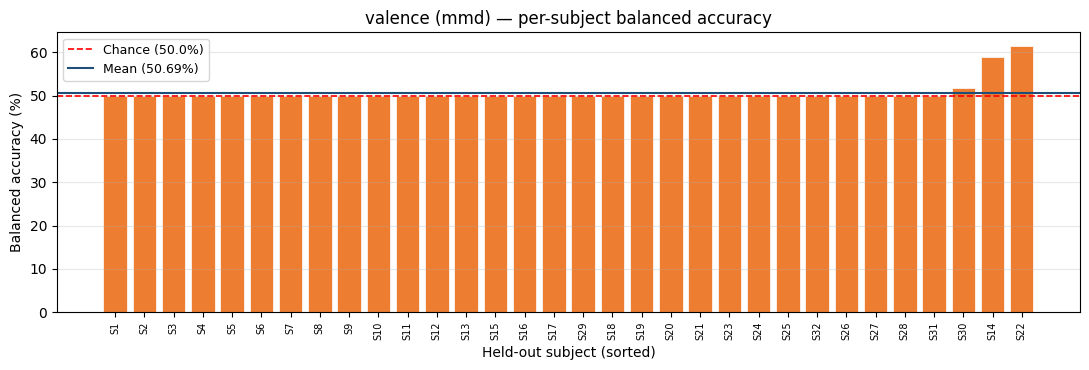

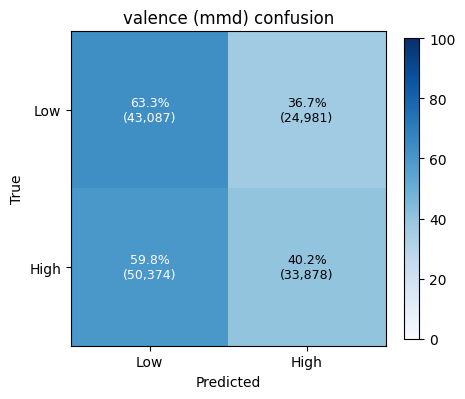

In [16]:
import matplotlib.pyplot as plt

def plot_per_subject(task, variant):
    df = per_fold_all[(task, variant)].sort_values('bal').reset_index(drop=True)
    chance = 100.0 / get_n_classes(task)
    mean_bal = df['bal'].mean()
    fig, ax = plt.subplots(figsize=(11, 3.8))
    colors = ['#c0392b' if v < chance else '#ED7D31' for v in df['bal']]
    ax.bar(range(len(df)), df['bal'], color=colors, edgecolor='white', linewidth=0.5)
    ax.axhline(chance, color='red', linestyle='--', linewidth=1.2, label=f'Chance ({chance:.1f}%)')
    ax.axhline(mean_bal, color='#1F4E79', linewidth=1.5, label=f'Mean ({mean_bal:.2f}%)')
    ax.set_xlabel('Held-out subject (sorted)'); ax.set_ylabel('Balanced accuracy (%)')
    ax.set_title(f'{task} ({variant}) — per-subject balanced accuracy')
    ax.set_xticks(range(len(df)))
    ax.set_xticklabels([f'S{int(s)}' for s in df['sid']], rotation=90, fontsize=7)
    ax.legend(loc='upper left', fontsize=9); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    fig.savefig(RESULTS_DIR / f'per_subject_{task}_{variant}.png', dpi=140, bbox_inches='tight')
    plt.show()

def plot_confusion(task, variant):
    cm = cms_all[(task, variant)].astype(float)
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    n = cm.shape[0]
    names = (['Low','High'] if task in ('valence','arousal') else ['Neg','Neu','Pos'])
    fig, ax = plt.subplots(figsize=(4.8, 4.1))
    im = ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
    for i in range(n):
        for j in range(n):
            c = 'white' if cm_pct[i,j] > 50 else 'black'
            ax.text(j, i, f'{cm_pct[i,j]:.1f}%\n({int(cm[i,j]):,})', ha='center', va='center', color=c, fontsize=9)
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(names); ax.set_yticklabels(names)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{task} ({variant}) confusion')
    plt.colorbar(im, ax=ax, fraction=0.04)
    plt.tight_layout()
    fig.savefig(RESULTS_DIR / f'confusion_{task}_{variant}.png', dpi=140, bbox_inches='tight')
    plt.show()

# Flagship: valence + mmd (the primary R4 hypothesis)
plot_per_subject('valence', 'mmd')
plot_confusion('valence', 'mmd')

variant      plain       dann        mmd  delta_dann  delta_mmd
task                                                           
3class   38.357344  36.956538  34.300275   -1.400805  -4.057068
arousal  54.753908  53.250295  50.000000   -1.503612  -4.753908
valence  55.892004  54.075753  50.692023   -1.816251  -5.199981


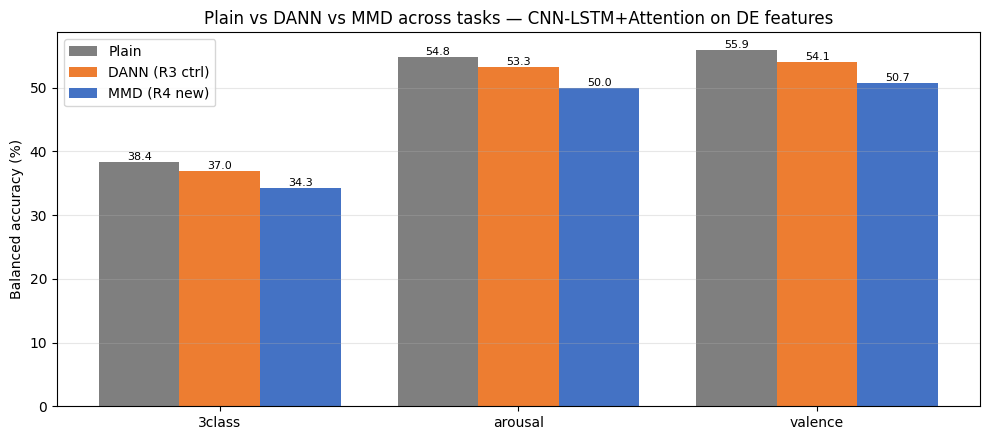

In [17]:
# Three-way variant comparison across tasks
pivot = SUMMARY.pivot_table(index='task', columns='variant', values='bal_mean')
pivot = pivot[['plain', 'dann', 'mmd']]
pivot['delta_dann'] = pivot['dann'] - pivot['plain']
pivot['delta_mmd']  = pivot['mmd']  - pivot['plain']
print(pivot)

fig, ax = plt.subplots(figsize=(10, 4.5))
tasks = pivot.index.tolist()
x = np.arange(len(tasks)); w = 0.27
ax.bar(x - w, pivot['plain'], w, label='Plain',       color='#7f7f7f')
ax.bar(x,     pivot['dann'],  w, label='DANN (R3 ctrl)', color='#ED7D31')
ax.bar(x + w, pivot['mmd'],   w, label='MMD (R4 new)',   color='#4472C4')
for i, task in enumerate(tasks):
    ax.text(i - w, pivot.loc[task, 'plain'] + 0.3, f'{pivot.loc[task, "plain"]:.1f}', ha='center', fontsize=8)
    ax.text(i,     pivot.loc[task, 'dann']  + 0.3, f'{pivot.loc[task, "dann"]:.1f}',  ha='center', fontsize=8)
    ax.text(i + w, pivot.loc[task, 'mmd']   + 0.3, f'{pivot.loc[task, "mmd"]:.1f}',   ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(tasks); ax.set_ylabel('Balanced accuracy (%)')
ax.set_title('Plain vs DANN vs MMD across tasks — CNN-LSTM+Attention on DE features')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'plain_vs_dann_vs_mmd.png', dpi=140, bbox_inches='tight')
plt.show()

## 10. Persistence
Per-fold CSVs and pooled confusion matrices for the Report 4 write-up.

In [18]:
for key, df in per_fold_all.items():
    tag = '_'.join(key)
    df.to_csv(RESULTS_DIR / f'per_fold_{tag}.csv', index=False)
for key, cm in cms_all.items():
    tag = '_'.join(key)
    np.save(RESULTS_DIR / f'cm_{tag}.npy', cm)

print('Saved to:', RESULTS_DIR)

Saved to: /content/drive/MyDrive/case_study_2/results/report4_msda
